## Load Required Libraries And Datasets

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#### Load The Airbnb data
df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\AirBNB\air-bnb-listings.csv",
                 delimiter=';',
                 engine='python', 
                 encoding='utf-8-sig',
                 on_bad_lines='skip')



In [3]:
#### Rename columns

df.rename(columns={
    'Room ID': 'room_id',
    'Name': 'name',
    'Host ID': 'host_id',
    'Neighbourhood': 'neighbourhood',
    'Room type': 'room_type',
    'Room Price': 'room_price',
    'Minimum nights': 'minimum_nights',
    'Number of reviews': 'number_of_reviews',
    'Date last review': 'last_review_date',
    'Number of reviews per month': 'reviews_per_month',
    'Rooms rent by the host': 'rooms_by_host',
    'Availibility': 'availability',
    'Updated Date': 'updated_date',   # will drop this next
    'City': 'city',
    'Country': 'country',
    'Coordinates': 'coordinates',
    'Location': 'location'
}, inplace=True)

#### Drop only 'updated_date' column
df.drop(columns=['updated_date'], inplace=True)

print("✅ Columns renamed and cleaned successfully!")


✅ Columns renamed and cleaned successfully!


In [4]:
#### Now split the 'coordinates' column
df[['latitude', 'longitude']] = df['coordinates'].str.split(',', expand=True)

#### Convert them to float (important!)
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)

#### Drop old 'coordinates' column if you don't need it anymore
df.drop(columns=['coordinates'], inplace=True)

print("✅ Coordinates successfully split into Latitude and Longitude!")


✅ Coordinates successfully split into Latitude and Longitude!


In [5]:
df
df.head()

,room_id,name,host_id,neighbourhood,room_type,room_price,minimum_nights,number_of_reviews,last_review_date,reviews_per_month,rooms_by_host,availability,city,country,location,latitude,longitude
0,9153958,.2 La Casa sui Tetti dell'Oltrarno,47655975,Centro Storico,Entire home/apt,50,1,363,2020-02-17,6.69,2,0,Florence,Italy,"Italy, Florence, Centro Storico",43.766789,11.245890
1,9191572,Firenze Studio Porta Romana,47816872,Centro Storico,Entire home/apt,70,2,46,2018-03-15,0.83,1,364,Florence,Italy,"Italy, Florence, Centro Storico",43.765447,11.242550
2,9306481,ELEGANT FLAT FLORENCE CITY CENTER,42112573,Centro Storico,Entire home/apt,120,2,132,2020-01-29,2.42,1,270,Florence,Italy,"Italy, Florence, Centro Storico",43.779967,11.261314
3,9524225,Luxury Modern Studio - Florence,11065786,Campo di Marte,Entire home/apt,75,3,56,2019-12-30,1.01,5,364,Florence,Italy,"Italy, Florence, Campo di Marte",43.768156,11.275231
4,9602552,Florence is a dream,956926,Campo di Marte,Entire home/apt,50,2,24,2018-10-27,0.44,1,365,Florence,Italy,"Italy, Florence, Campo di Marte",43.788093,11.273348


In [6]:
#### Remove any "$" or commas if present

df['room_price'] = df['room_price'].replace('[\$,]', '', regex=True).astype(float)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1414018 entries, 0 to 1414017
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   room_id            1414018 non-null  int64  
 1   name               1413310 non-null  object 
 2   host_id            1414018 non-null  int64  
 3   neighbourhood      1414018 non-null  object 
 4   room_type          1414018 non-null  object 
 5   room_price         1414018 non-null  float64
 6   minimum_nights     1414018 non-null  int64  
 7   number_of_reviews  1414018 non-null  int64  
 8   last_review_date   1035700 non-null  object 
 9   reviews_per_month  1019175 non-null  float64
 10  rooms_by_host      1414018 non-null  int64  
 11  availability       1414018 non-null  int64  
 12  city               1414018 non-null  object 
 13  country            1414018 non-null  object 
 14  location           1414018 non-null  object 
 15  latitude           1414018 non-n

In [8]:
#### Handle Missing Values
#### Fill reviews_per_month with 0 where NaN

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

#### Fill number_of_reviews with 0 where NaN
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

df['last_review_date'] = df['number_of_reviews'].fillna(0)


In [9]:
#### Drop rows where room_price is missing or 0 (because you can't predict)
df = df[df['room_price'] > 0]

#### Drop rows where room_type, city, country is missing
df = df.dropna(subset=['room_type', 'city', 'country','name'])

#### Remove Outlier Prices (> $1000)
#### df = df[df['room_price'] <= 2000]

In [10]:
#### Final Check
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1413001 entries, 0 to 1414017
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   room_id            1413001 non-null  int64  
 1   name               1413001 non-null  object 
 2   host_id            1413001 non-null  int64  
 3   neighbourhood      1413001 non-null  object 
 4   room_type          1413001 non-null  object 
 5   room_price         1413001 non-null  float64
 6   minimum_nights     1413001 non-null  int64  
 7   number_of_reviews  1413001 non-null  int64  
 8   last_review_date   1413001 non-null  int64  
 9   reviews_per_month  1413001 non-null  float64
 10  rooms_by_host      1413001 non-null  int64  
 11  availability       1413001 non-null  int64  
 12  city               1413001 non-null  object 
 13  country            1413001 non-null  object 
 14  location           1413001 non-null  object 
 15  latitude           1413001 non-n

In [11]:
df.head()

,room_id,name,host_id,neighbourhood,room_type,room_price,minimum_nights,number_of_reviews,last_review_date,reviews_per_month,rooms_by_host,availability,city,country,location,latitude,longitude
0,9153958,.2 La Casa sui Tetti dell'Oltrarno,47655975,Centro Storico,Entire home/apt,50.0,1,363,363,6.69,2,0,Florence,Italy,"Italy, Florence, Centro Storico",43.766789,11.245890
1,9191572,Firenze Studio Porta Romana,47816872,Centro Storico,Entire home/apt,70.0,2,46,46,0.83,1,364,Florence,Italy,"Italy, Florence, Centro Storico",43.765447,11.242550
2,9306481,ELEGANT FLAT FLORENCE CITY CENTER,42112573,Centro Storico,Entire home/apt,120.0,2,132,132,2.42,1,270,Florence,Italy,"Italy, Florence, Centro Storico",43.779967,11.261314
3,9524225,Luxury Modern Studio - Florence,11065786,Campo di Marte,Entire home/apt,75.0,3,56,56,1.01,5,364,Florence,Italy,"Italy, Florence, Campo di Marte",43.768156,11.275231
4,9602552,Florence is a dream,956926,Campo di Marte,Entire home/apt,50.0,2,24,24,0.44,1,365,Florence,Italy,"Italy, Florence, Campo di Marte",43.788093,11.273348


In [12]:
print(df.isnull().values)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [13]:
max_price = df['room_price'].max()
print(f"The max price is :{max_price}")

The max price is :224878135.0


In [16]:
Row_with_max_price = df[df['room_price']==max_price] 
print("\n Row with maximum price.")
print(Row_with_max_price)


 Row with maximum price.
         room_id                                              name    host_id  \
229110  26003806  19.Zip Apartments -El Golf - Depto SUPERIOR KING  144127724   

       neighbourhood   room_type   room_price  minimum_nights  \
229110    Las Condes  Hotel room  224878135.0               3   

        number_of_reviews  last_review_date  reviews_per_month  rooms_by_host  \
229110                  3                 3               0.13             30   

        availability      city country                     location  \
229110           364  Santiago   Chile  Chile, Santiago, Las Condes   

         latitude  longitude  
229110 -33.413939  -70.58545  


In [13]:
#### Save Cleaned Dataset
df.to_csv('cleaned_airbnb_data.csv', index=False)

## Exploratory Data Analysis (EDA)

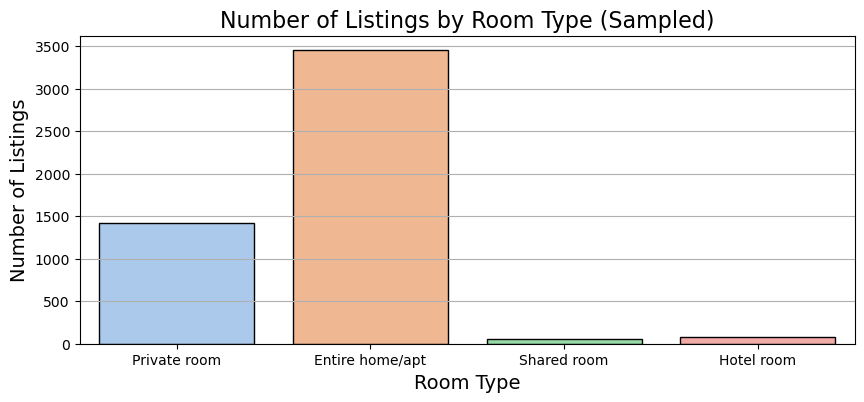

In [22]:
#### Sample 5000 rows first (same as before)
sample_df = df.sample(n=5000, random_state=42)

#### Now plot Room Type Count
plt.figure(figsize=(10,4))
sns.countplot(x='room_type', data=sample_df, palette='pastel', edgecolor='black')

plt.title('Number of Listings by Room Type (Sampled)', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Number of Listings', fontsize=14)
plt.grid(axis='y')
plt.show()

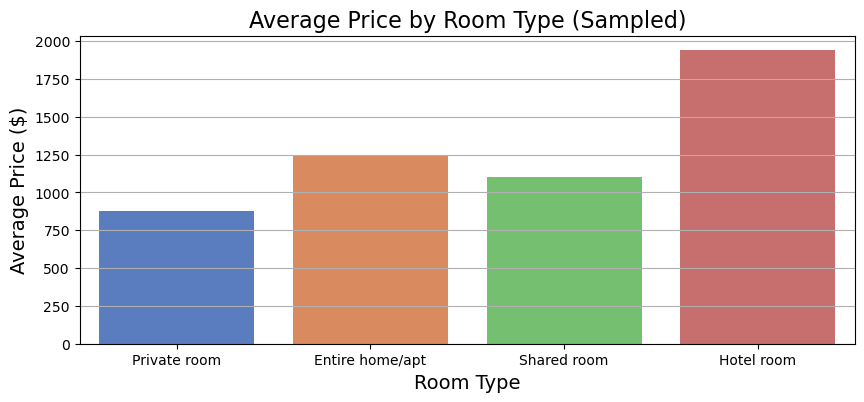

In [25]:
#### Sample first (safe side)
sample_df = df.sample(n=5000, random_state=42)

#### Plot Room Type vs Average Price
plt.figure(figsize=(10,4))
sns.barplot(x='room_type', y='room_price', data=sample_df, palette='muted', errorbar=None)

plt.title('Average Price by Room Type (Sampled)', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Average Price ($)', fontsize=14)
plt.grid(axis='y')
plt.show()

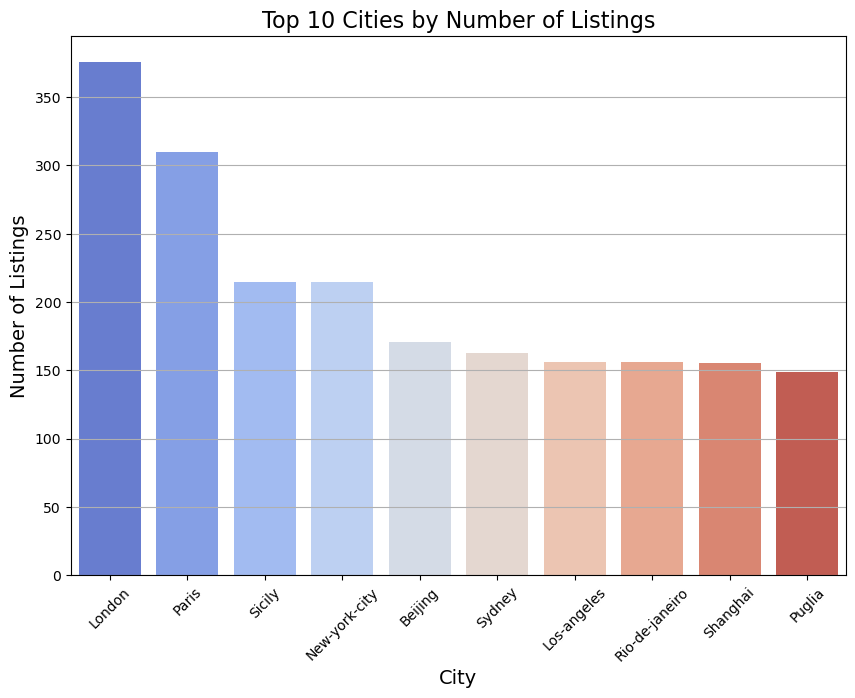

In [28]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Top 10 cities by number of listings 
plt.figure(figsize=(10,7))
top_cities = sample_df['city'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette='coolwarm')

plt.title('Top 10 Cities by Number of Listings', fontsize=16)
plt.xlabel('City', fontsize=14)
plt.ylabel('Number of Listings', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

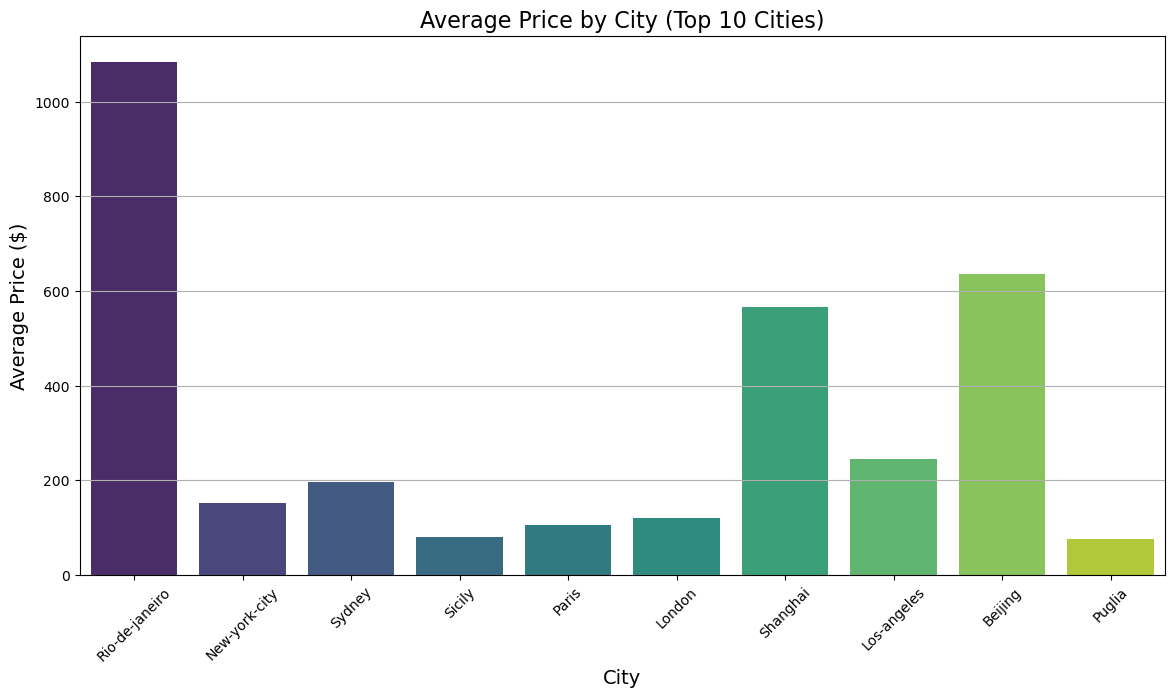

In [30]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Average price in top 10 cities
top_cities_list = top_cities.index.tolist()

plt.figure(figsize=(14,7))
sns.barplot(x='city', y='room_price', data=sample_df[sample_df['city'].isin(top_cities_list)], palette='viridis', errorbar=None)

plt.title('Average Price by City (Top 10 Cities)', fontsize=16)
plt.xlabel('City', fontsize=14)
plt.ylabel('Average Price ($)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

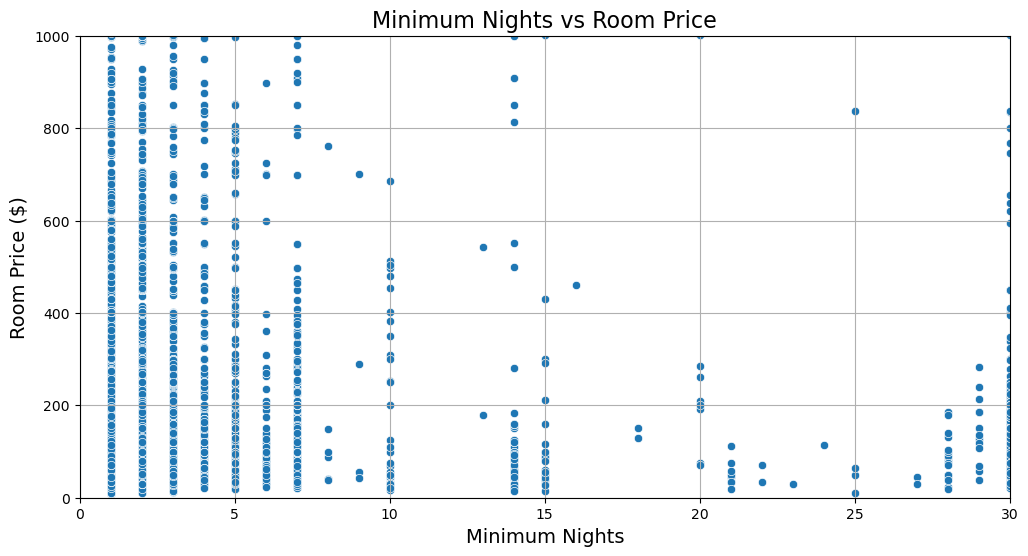

In [33]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Minimum nights Vs Room prices (Scatter plot)
plt.figure(figsize=(12,6))
sns.scatterplot(x='minimum_nights', y='room_price', data=sample_df)

plt.title('Minimum Nights vs Room Price', fontsize=16)
plt.xlabel('Minimum Nights', fontsize=14)
plt.ylabel('Room Price ($)', fontsize=14)
plt.xlim(0, 30)   # Focus on bookings <= 30 days
plt.ylim(0, 1000) # Focus on realistic prices
plt.grid(True)
plt.show()

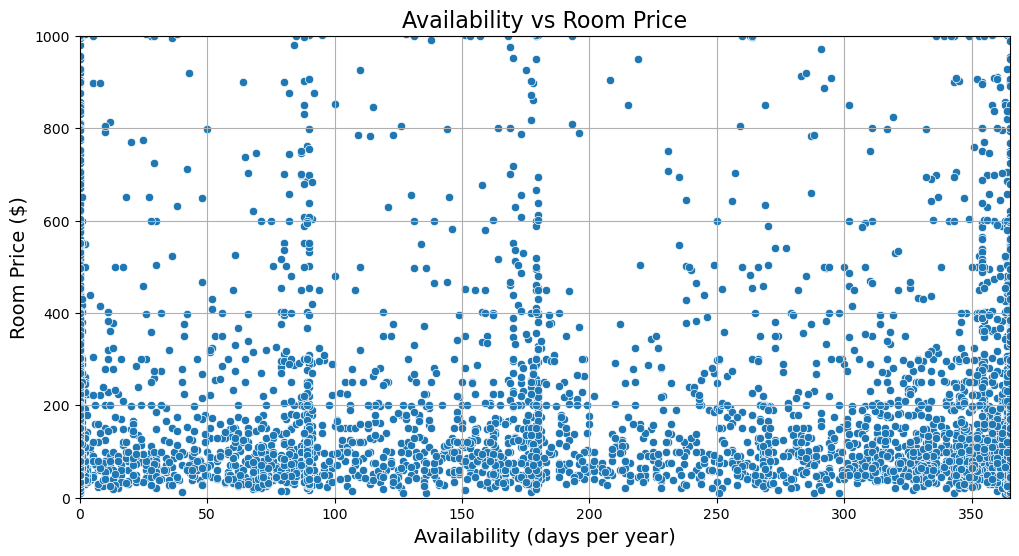

In [34]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Availability Vs room price ( Scatter Plot)
plt.figure(figsize=(12,6))
sns.scatterplot(x='availability', y='room_price', data=sample_df)

plt.title('Availability vs Room Price', fontsize=16)
plt.xlabel('Availability (days per year)', fontsize=14)
plt.ylabel('Room Price ($)', fontsize=14)
plt.xlim(0, 365)
plt.ylim(0, 1000)
plt.grid(True)
plt.show()

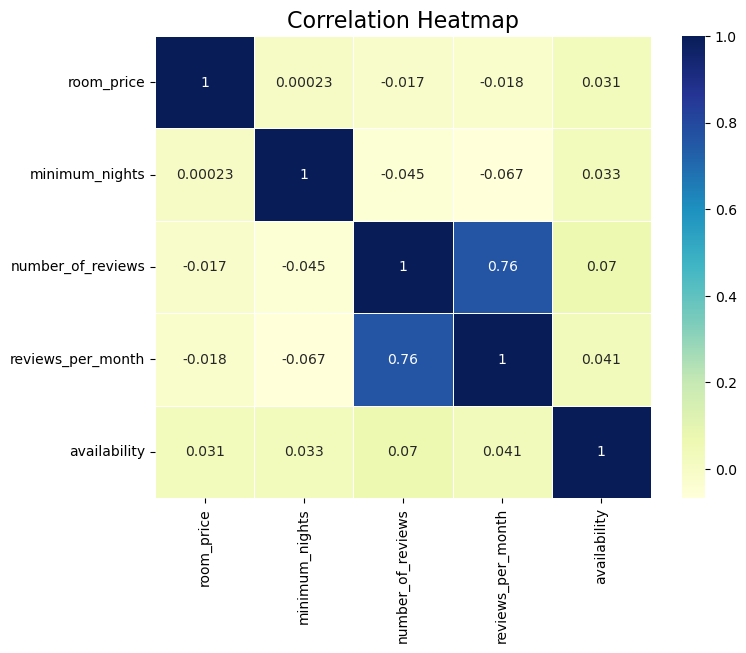

In [37]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Correlation Heatmap
plt.figure(figsize=(8,6))
corr = sample_df[['room_price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability']].corr()

sns.heatmap(corr, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

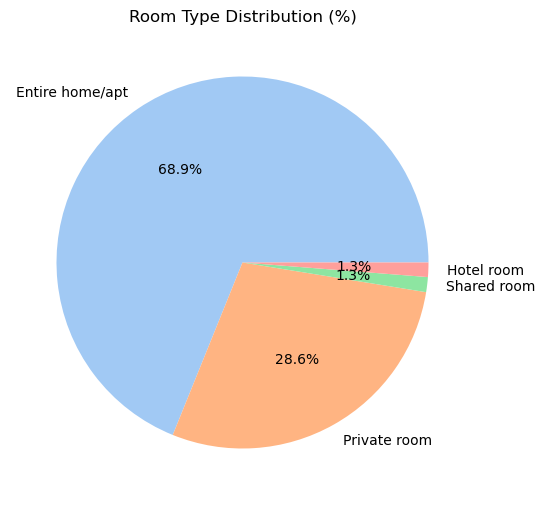

In [39]:
#### Sample first (safe side)
sample_df = df.sample(n=6000, random_state=45)

#### Room Type pie chart
room_counts = sample_df['room_type'].value_counts()

plt.figure(figsize=(6,8))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Room Type Distribution (%)')
plt.show()